In [ ]:
!pip install -q transformers

import torch
import math
import time
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_id = "gpt2"  # small, Colab-friendly

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
).to(device)
model.eval()

# We'll study the first MLP "c_fc" layer in the first transformer block
target_layer = model.transformer.h[0].mlp.c_fc
print("Target layer:", target_layer)

def quantize_int8_per_tensor(x: torch.Tensor):
    max_val = x.abs().max()
    if max_val == 0:
        return torch.zeros_like(x, dtype=torch.int8), 1.0
    scale = max_val / 127.0
    q = torch.round(x / scale).clamp(-127, 127).to(torch.int8)
    return q, scale

def dequantize_int8(q: torch.Tensor, scale: float):
    return q.to(torch.float32) * scale



In [ ]:
acts = []

def capture_activations(module, input, output):
    # input[0]: (batch, seq, hidden)
    x = input[0].detach().cpu()
    acts.append(x)

hook = target_layer.register_forward_hook(capture_activations)

calib_texts = [
    "Quantization allows us to compress large language models efficiently.",
    "SmoothQuant redistributes quantization difficulty between weights and activations.",
    "Activation outliers can hurt INT8 quantization if we ignore them.",
    "By scaling activations and weights, we can enable accurate W8A8 LLMs.",
    "Large transformers like GPT-2 often have very spiky activations in early layers.",
]

with torch.no_grad():
    for text in calib_texts:
        enc = tokenizer(text, return_tensors="pt").to(device)
        _ = model(**enc)

hook.remove()

# Flatten all tokens into a 2D matrix: [N_tokens, hidden_dim]
X_flat = torch.cat([a.reshape(-1, a.size(-1)) for a in acts], dim=0)  # [N, H]
W = target_layer.weight.detach().cpu()  # [out_features, in_features]

print("X_flat shape:", X_flat.shape)
print("W shape:", W.shape)



X_flat shape: torch.Size([77, 768])
W shape: torch.Size([768, 3072])
max_x shape: torch.Size([768])
max_w shape: torch.Size([768])
Scaling stats: s min = 0.2203417271375656 max = 1.7429778575897217


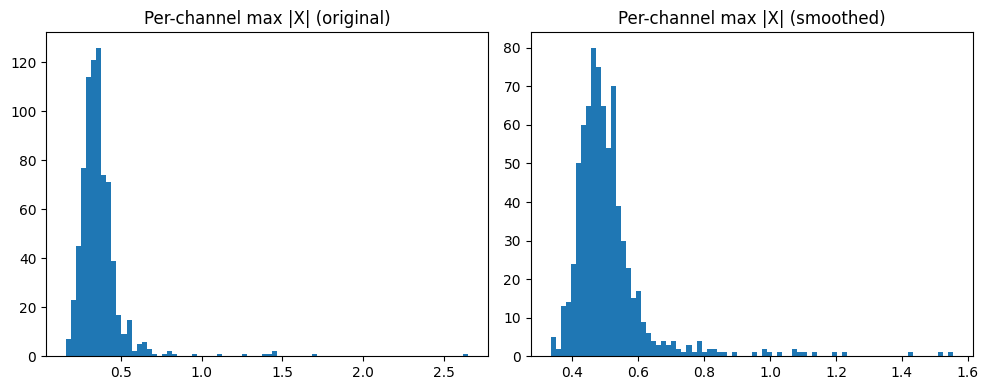

In [ ]:
# ---- Inspect shapes ----
print("X_flat shape:", X_flat.shape)   # [N, H_in]
print("W shape:", W.shape)             # here: [H_in, H_out] = [768, 3072]

in_features = X_flat.shape[1]

# Per-channel maxima for activations: along feature dim
max_x = X_flat.abs().max(dim=0).values  # [H_in]

# Per-channel maxima for weights: align with input channels
if W.shape[0] == in_features:
    # W is [H_in, H_out] -> take max over output dim
    max_w = W.abs().max(dim=1).values   # [H_in]
elif W.shape[1] == in_features:
    # W is [H_out, H_in] -> take max over output dim
    max_w = W.abs().max(dim=0).values   # [H_in]
else:
    raise ValueError(f"Cannot align W with X: in_features={in_features}, W.shape={W.shape}")

print("max_x shape:", max_x.shape)
print("max_w shape:", max_w.shape)

# ---- SmoothQuant scaling factors ----
alpha = 0.5  # typical range 0.4–0.6
eps = 1e-8

s = (max_x.pow(alpha) / (max_w.pow(1 - alpha) + eps))  # [H_in]

# Clip s to avoid extreme scaling
s = torch.clamp(s, min=0.01, max=100.0)

# ---- Apply SmoothQuant-style transform ----
# W: [H_in, H_out], s: [H_in] → reshape to [H_in, 1] so we scale each *row*
W_smooth = W * s.view(-1, 1)   # [H_in, H_out]
# X_flat: [N, H_in] → divide along last dim
X_smooth = X_flat / s          # [N, H_in]

print("Scaling stats: s min =", s.min().item(), "max =", s.max().item())

# ---- Compare activation dynamic range before/after ----
max_x_smooth = X_smooth.abs().max(dim=0).values

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(max_x.numpy(), bins=80)
plt.title("Per-channel max |X| (original)")

plt.subplot(1, 2, 2)
plt.hist(max_x_smooth.numpy(), bins=80)
plt.title("Per-channel max |X| (smoothed)")

plt.tight_layout()
plt.show()


In [ ]:
# Full-precision reference output for this layer on calibration activations
Y_full = X_flat @ W  # [N, out_features] = [77, 3072]

# ---- Naive W8A8: quantize X and W directly ----
W_q, W_scale = quantize_int8_per_tensor(W)         # [768, 3072] -> int8
X_q, X_scale = quantize_int8_per_tensor(X_flat)    # [77, 768]   -> int8

Y_naive = dequantize_int8(X_q, X_scale) @ dequantize_int8(W_q, W_scale)  # [77, 3072]
mse_naive = torch.mean((Y_full - Y_naive) ** 2).item()

# ---- SmoothQuant-style W8A8 ----
W_sq_q, W_sq_scale = quantize_int8_per_tensor(W_smooth)      # [768, 3072]
X_sq_q, X_sq_scale = quantize_int8_per_tensor(X_smooth)      # [77, 768]

Y_smooth = dequantize_int8(X_sq_q, X_sq_scale) @ dequantize_int8(W_sq_q, W_sq_scale)
mse_smooth = torch.mean((Y_full - Y_smooth) ** 2).item()

print(f"Naive W8A8 MSE:       {mse_naive:.6e}")
print(f"SmoothQuant W8A8 MSE: {mse_smooth:.6e}")
